# Lab: Customer Segmentation and Student Performance Prediction
# **SOLUTIONS VERSION**

## Objectives

In this lab, you will apply the machine learning techniques you learned in class to real-world datasets:

1. **Part 1: Customer Segmentation with K-Means Clustering**
   - Load and explore customer data
   - Apply K-means clustering to identify customer segments
   - Predict which segment a new customer belongs to

2. **Part 2: Student Performance Prediction with Linear Regression**
   - Load and explore student performance data
   - Use a linear regression model to predict exam scores
   - Make predictions for new students

---
# Part 1: Customer Segmentation with K-Means Clustering

## Background

You work for a retail company that wants to understand its customer base better. The company has collected data on customers' annual income and spending scores (a metric from 1-100 indicating how much they spend). Your task is to use **K-means clustering** to identify distinct customer segments.

### Why is this useful?
By identifying customer segments, the company can:
- Target marketing campaigns to specific groups
- Develop products tailored to different customer needs
- Optimize pricing strategies for each segment

## Step 1: Import Libraries and Load Data

First, we need to import the necessary Python libraries and load our customer data from the CSV file.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the customer data
customers = pd.read_csv('customer_segmentation.csv')

# Display the first few rows to understand the data
customers.head()

,CustomerID,AnnualIncome_k$,SpendingScore
0,45,50.1,80.3
1,48,57.0,84.8
2,5,28.8,23.2
3,56,46.2,64.1
4,27,24.2,34.4


### Question 1.1: Explore the Data

Before applying any machine learning algorithm, we should always explore our data first.

**Task:** Answer the following questions by examining the data:
1. How many customers are in the dataset?
2. What are the column names?
3. What is the range of annual incomes? (hint: use `.min()` and `.max()`)
4. What is the range of spending scores?

In [2]:
# Explore the data
print(f"Number of customers: {customers.shape[0]}")

# Print column names
print(f"\nColumn names: {list(customers.columns)}")

# Find the range of AnnualIncome_k$
print(f"\nIncome range: ${customers['AnnualIncome_k$'].min():.1f}k to ${customers['AnnualIncome_k$'].max():.1f}k")

# Find the range of SpendingScore
print(f"Spending score range: {customers['SpendingScore'].min():.1f} to {customers['SpendingScore'].max():.1f}")

Number of customers: 120

Column names: ['CustomerID', 'AnnualIncome_k$', 'SpendingScore']

Income range: $20.2k to $99.0k
Spending score range: 14.0 to 90.3


**Answers:**
1. There are 120 customers in the dataset
2. Columns: CustomerID, AnnualIncome\_k\$, SpendingScore
3. Income ranges from about \\$20k to \\$99k
4. Spending scores range from about 14 to 90

## Step 2: Visualize the Data

Before clustering, it's helpful to visualize the data to get an intuition about potential groupings.

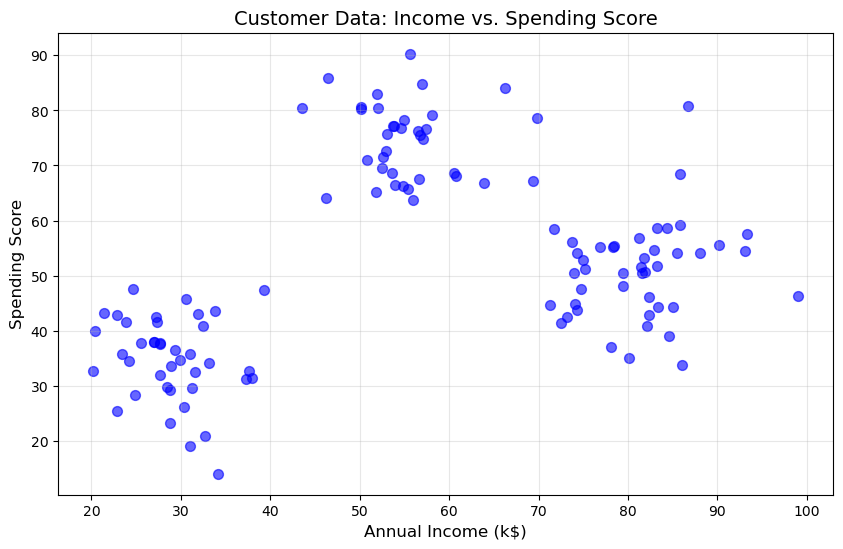

In [3]:
# Create a scatter plot of the data
plt.figure(figsize=(10, 6))
plt.scatter(customers['AnnualIncome_k$'], customers['SpendingScore'], 
            alpha=0.6, s=50, c='blue')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title('Customer Data: Income vs. Spending Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### Question 1.2: Visual Inspection

Looking at the scatter plot above:
- How many distinct groups do you think might exist in the data?
- Describe what you see in words.

**Answer:** Looking at the scatter plot, there appear to be 3 distinct groups:
1. Low income, low spending (bottom left)
2. Medium income, high spending (top middle)
3. High income, medium spending (middle right)

## Step 3: Prepare Data for K-Means

$\color{#EF5645}{\text{Reminder}}$: K-means works with numerical arrays, not DataFrames. We need to extract the features we want to cluster.

For our clustering, we'll use:
- **Feature 1:** Annual Income (k$)
- **Feature 2:** Spending Score

We'll ignore CustomerID since it's just an identifier, not a meaningful feature.

In [4]:
# Extract the feature columns into a numpy array X
X = customers[['AnnualIncome_k$', 'SpendingScore']].values

# Verify the shape
print(f"Shape of X: {X.shape}")
print(f"First 5 data points:")
print(X[:5])

Shape of X: (120, 2)
First 5 data points:
[[50.1 80.3]
 [57.  84.8]
 [28.8 23.2]
 [46.2 64.1]
 [24.2 34.4]]


## Step 4: Implement the K-Means Algorithm

$\color{#047C91}{\text{Recall from lecture}}$: The K-means algorithm has two main steps that repeat:

1. **Assignment step:** Assign each point to the nearest representative (cluster center)
2. **Update step:** Update each representative to be the mean of all points assigned to it

We'll implement a K-means function similar to what you saw in lecture.

In [5]:
def k_means_clustering(X, k, max_iterations=100, tolerance=0.1):
    """
    Perform K-means clustering on data X.
    
    Parameters:
    -----------
    X : numpy array of shape (n_samples, n_features)
        The data to cluster
    k : int
        The number of clusters
    max_iterations : int
        Maximum number of iterations
    tolerance : float
        If representatives move less than this distance, stop iterating
    
    Returns:
    --------
    representatives : numpy array of shape (k, n_features)
        The final cluster centers
    assignments : list of length n_samples
        The cluster assignment for each data point
    """
    
    # Initialize representatives as the first k data points
    representatives = np.copy(X[:k])
    
    for iteration in range(max_iterations):
        # Store the old representatives to check for convergence
        old_representatives = np.copy(representatives)
        
        # ------ ASSIGNMENT STEP ------
        # For each point in X, find which representative is closest
        
        X_per_cluster = [[] for _ in range(k)]  # List to store points in each cluster
        assignments = []  # List to store cluster assignments
        
        for x in X:
            # Calculate distances from x to each representative
            distances = [np.linalg.norm(x - rep) for rep in representatives]
            
            # Find which cluster is closest
            closest_cluster = np.argmin(distances)
            
            # Add this point to the appropriate cluster
            assignments.append(closest_cluster)
            X_per_cluster[closest_cluster].append(x)
        
        # ------ UPDATE STEP ------
        # Update each representative to be the mean of its assigned points
        for j in range(k):
            if len(X_per_cluster[j]) > 0:  # Check cluster is not empty
                representatives[j] = np.mean(X_per_cluster[j], axis=0)
        
        # Check for convergence
        movement = np.linalg.norm(representatives - old_representatives)
        if movement < tolerance:
            print(f"Converged after {iteration + 1} iterations")
            break
    
    return representatives, assignments

### Question 1.3: Understanding the Algorithm

Before running the code, what does the `movement` variable represent?

**Answers:**
The `movement` variable measures how much the cluster centers moved between iterations. When this is small, the algorithm has converged.

## Step 5: Apply K-Means with k=3 Clusters

Based on our visual inspection, let's try k=3 clusters.

In [6]:
# Apply K-means with k=3
k = 3
representatives, assignments = k_means_clustering(X, k=k)

print(f"\nFinal cluster centers (representatives):")
for i, rep in enumerate(representatives):
    print(f"Cluster {i}: Income=${rep[0]:.1f}k, Spending Score={rep[1]:.1f}")

Converged after 3 iterations

Final cluster centers (representatives):
Cluster 0: Income=$55.3k, Spending Score=74.4
Cluster 1: Income=$81.1k, Spending Score=50.7
Cluster 2: Income=$28.9k, Spending Score=34.8


## Step 6: Visualize the Clustering Results

Let's plot the data points colored by their cluster assignment and show the cluster centers.

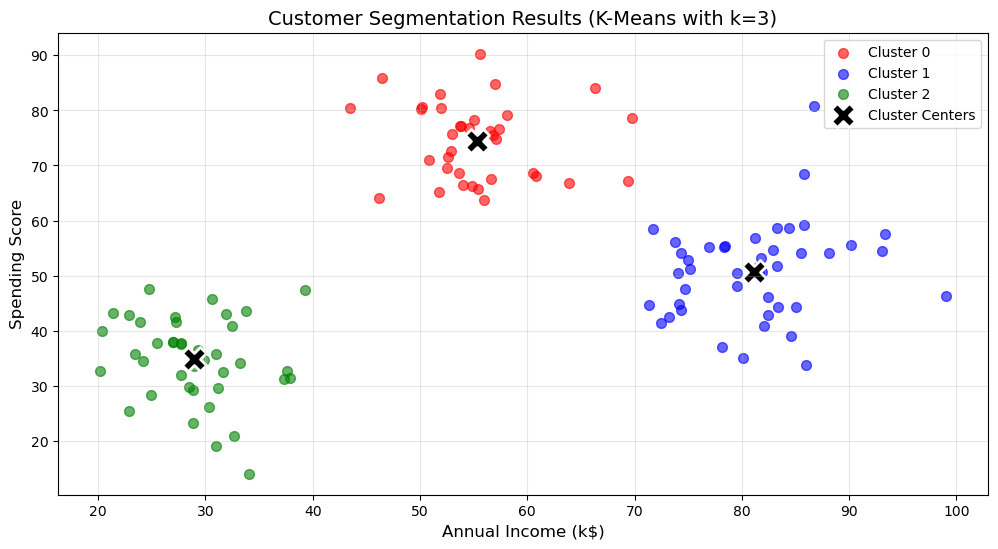

In [7]:
# Define colors for each cluster
colors = ['red', 'blue', 'green', 'purple', 'orange']

plt.figure(figsize=(12, 6))

# Plot each cluster with a different color
for cluster_id in range(k):
    # Get all points in this cluster
    cluster_points = X[np.array(assignments) == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.6, s=50)

# Plot the cluster centers as large black X's
plt.scatter(representatives[:, 0], representatives[:, 1], 
            c='black', marker='X', s=300, 
            label='Cluster Centers', edgecolors='white', linewidths=2)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title('Customer Segmentation Results (K-Means with k=3)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 7: Predict Cluster for New Customers

Now comes an important task: **using your trained model to make predictions on new data!**

The company has information about three new customers and wants to know which segment each belongs to.

$\color{#EF5645}{\text{Key Insight}}$: To predict which cluster a new point belongs to, we:
1. Calculate the distance from the new point to each cluster center
2. Assign it to the nearest cluster center

In [8]:
def predict_cluster(new_point, representatives):
    """
    Predict which cluster a new point belongs to.
    
    Parameters:
    -----------
    new_point : numpy array of shape (n_features,)
        The new data point to classify
    representatives : numpy array of shape (k, n_features)
        The cluster centers from K-means
    
    Returns:
    --------
    cluster_id : int
        The predicted cluster assignment
    """
    # Calculate distances from new_point to each representative
    distances = [np.linalg.norm(new_point - rep) for rep in representatives]
    
    # Return the index of the closest cluster
    return np.argmin(distances)

### Test Your Prediction Function

Let's predict the cluster for three new customers:

In [9]:
# New customers: [Annual Income (k$), Spending Score]
new_customers = [
    np.array([25, 30]),   # Customer A: Low income, low spending
    np.array([60, 80]),   # Customer B: Medium income, high spending  
    np.array([85, 45]),   # Customer C: High income, medium spending
]

customer_names = ['A', 'B', 'C']

# Predict clusters for new customers
print("Predictions for new customers:\n")
for i, customer in enumerate(new_customers):
    predicted_cluster = predict_cluster(customer, representatives)
    print(f"Customer {customer_names[i]}: Income=${customer[0]}k, "
          f"Spending={customer[1]} -> Predicted Cluster {predicted_cluster}")

Predictions for new customers:

Customer A: Income=$25k, Spending=30 -> Predicted Cluster 2
Customer B: Income=$60k, Spending=80 -> Predicted Cluster 0
Customer C: Income=$85k, Spending=45 -> Predicted Cluster 1


### Visualize Predictions

Let's add the new customers to our plot to see where they fall:

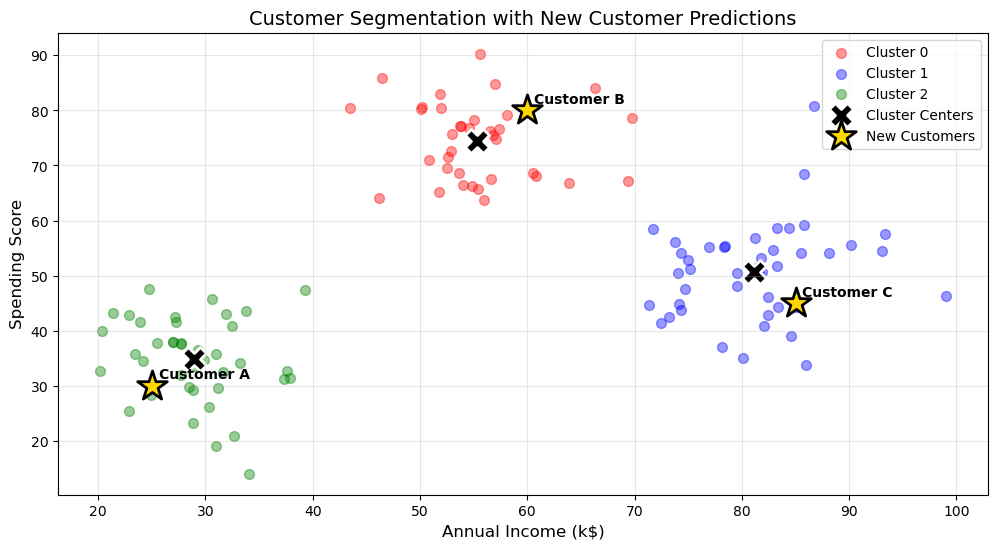

In [10]:
plt.figure(figsize=(12, 6))

# Plot existing clusters
for cluster_id in range(k):
    cluster_points = X[np.array(assignments) == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.4, s=50)

# Plot cluster centers
plt.scatter(representatives[:, 0], representatives[:, 1], 
            c='black', marker='X', s=300, 
            label='Cluster Centers', edgecolors='white', linewidths=2)

# Plot new customers
new_customers_array = np.array(new_customers)
plt.scatter(new_customers_array[:, 0], new_customers_array[:, 1],
            c='gold', marker='*', s=500, edgecolors='black', linewidths=2,
            label='New Customers', zorder=5)

# Add labels for new customers
for i, name in enumerate(customer_names):
    plt.annotate(f'Customer {name}', 
                xy=(new_customers[i][0], new_customers[i][1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title('Customer Segmentation with New Customer Predictions', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Question 1.4: Validate Your Predictions

Looking at the visualization:
1. Do the predicted clusters for the new customers make sense based on their positions?
2. Create your own new customer with features [Income, Spending] and predict their cluster. Choose values that you think will be challenging or interesting.

**Sample Answer:** Yes, the predictions make sense visually - each new customer is assigned to the cluster whose center is nearest to it.

In [11]:
# Example: Create your own new customer and predict their cluster
my_customer = np.array([50, 50])  # Medium income, medium spending

# Predict the cluster
my_prediction = predict_cluster(my_customer, representatives)
print(f"My customer: Income=${my_customer[0]}k, Spending={my_customer[1]}")
print(f"Predicted Cluster: {my_prediction}")

My customer: Income=$50k, Spending=50
Predicted Cluster: 0


---
# Part 2: Student Performance Prediction with Linear Regression

## Background

You're working with a university to help predict student exam scores. The university has data on:
- **StudyHours:** Hours spent studying per week
- **PreviousScore:** Score on a previous exam (out of 100)
- **ExamScore:** Score on the current exam (out of 100)

Your task is to use a **linear regression model** that predicts exam scores based on study hours and previous scores.

### Why is this useful?
- Students can estimate what score they might get based on their study habits
- The university can identify students who might need extra support
- We can understand which factors most strongly influence exam performance

## Step 1: Load and Explore the Student Data

In [12]:
# Load the student_performance.csv file
students = pd.read_csv('student_performance.csv')

# Display first few rows
students.head(10)

,StudentID,StudyHours,PreviousScore,ExamScore
0,1,29.4,78.0,92.5
1,2,15.0,83.3,85.6
2,3,12.9,63.7,77.0
3,4,24.3,64.6,89.7
4,5,30.2,71.3,93.6
5,6,19.8,83.2,87.3
6,7,39.3,89.6,100.0
7,8,29.0,79.4,95.3
8,9,21.8,89.9,93.7
9,10,18.7,73.5,88.7


In [13]:
# Explore the data
print(f"Number of students: {students.shape[0]}")
print(f"\nColumn names: {list(students.columns)}")
print(f"\nData statistics:")
students.describe()

Number of students: 100

Column names: ['StudentID', 'StudyHours', 'PreviousScore', 'ExamScore']

Data statistics:


,StudentID,StudyHours,PreviousScore,ExamScore
count,100.000000,100.000000,100.000000,100.000000
mean,50.500000,22.549000,77.686000,88.680000
std,29.011492,8.631578,10.010873,7.477873
min,1.000000,5.600000,60.100000,71.100000
25%,25.750000,16.175000,69.750000,83.450000
50%,50.500000,22.750000,79.250000,89.050000
75%,75.250000,29.200000,86.300000,94.325000
max,100.000000,39.800000,94.600000,100.000000


### Question 2.1: Data Exploration

1. What is the average study hours per week?
2. What is the average exam score?
3. What is the minimum and maximum exam score?

**Answers:**
1. Average study hours: ~22.5 hours per week
2. Average exam score: ~88.7
3. Exam scores range from 71.1 to 100

## Step 2: Visualize Relationships

Before building a model, let's visualize how exam scores relate to our features.

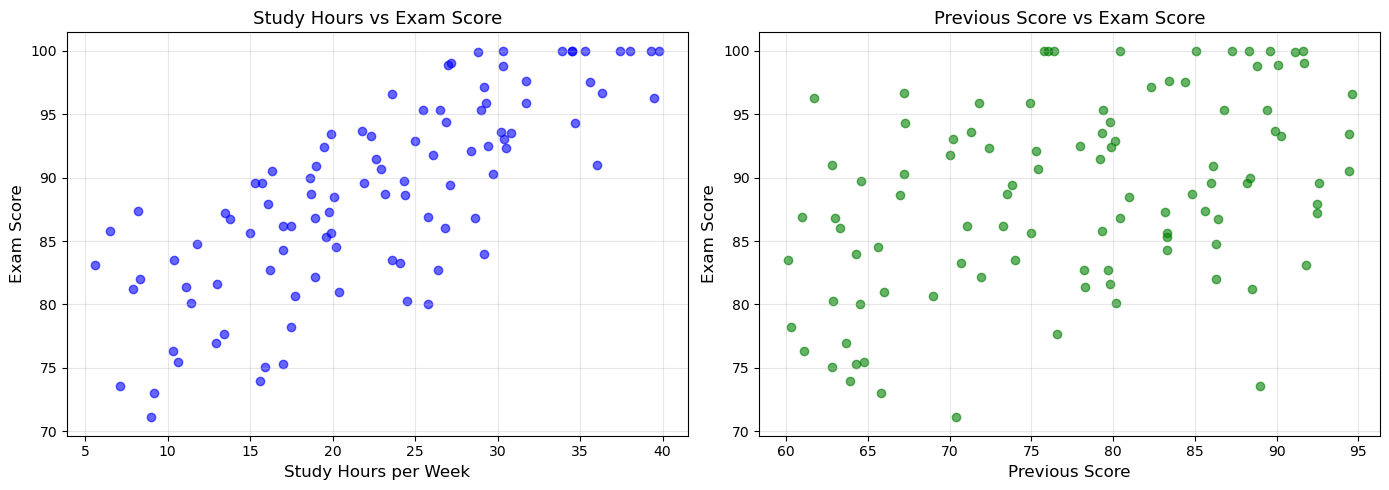

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Study Hours vs Exam Score
axes[0].scatter(students['StudyHours'], students['ExamScore'], alpha=0.6, c='blue')
axes[0].set_xlabel('Study Hours per Week', fontsize=12)
axes[0].set_ylabel('Exam Score', fontsize=12)
axes[0].set_title('Study Hours vs Exam Score', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Plot 2: Previous Score vs Exam Score
axes[1].scatter(students['PreviousScore'], students['ExamScore'], alpha=0.6, c='green')
axes[1].set_xlabel('Previous Score', fontsize=12)
axes[1].set_ylabel('Exam Score', fontsize=12)
axes[1].set_title('Previous Score vs Exam Score', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Question 2.2: Visual Analysis

Looking at the plots:
1. Does there appear to be a relationship between study hours and exam scores?
2. Does there appear to be a relationship between previous scores and exam scores?
3. Which relationship looks stronger?

**Answers:**
1. Yes, there is a positive relationship - students who study more tend to score higher.
2. Yes, there is a positive relationship - students with higher previous scores tend to score higher on the current exam.
3. Study hours seems to have a stronger relationship with exam score than previous score.

## Step 3: Prepare Data for Linear Regression

$\color{#EF5645}{\text{Recall from lecture}}$: In linear regression, we model the relationship as:

$$\hat{y} = w_1 x_1 + w_2 x_2 + b$$

Where:
- $\hat{y}$ is the predicted exam score
- $x_1$ is the study hours
- $x_2$ is the previous score
- $w_1, w_2$ are the weights (coefficients)
- $b$ is the bias (intercept)

In [15]:
# Extract features (X) and target (y)
X_features = students[['StudyHours', 'PreviousScore']].values
y_target = students['ExamScore'].values

print(f"X shape: {X_features.shape}")  # Should be (100, 2)
print(f"y shape: {y_target.shape}")    # Should be (100,)
print(f"\nFirst 5 feature vectors:")
print(X_features[:5])
print(f"\nFirst 5 target values:")
print(y_target[:5])

X shape: (100, 2)
y shape: (100,)

First 5 feature vectors:
[[29.4 78. ]
 [15.  83.3]
 [12.9 63.7]
 [24.3 64.6]
 [30.2 71.3]]

First 5 target values:
[92.5 85.6 77.  89.7 93.6]


## Step 4: Define the Linear Regression Model

$\color{#047C91}{\text{Recall from lecture}}$: We learned that a linear regression model uses weights and a bias to make predictions.

Find the best weights and bias for predicting exam scores:

- **Weight for Study Hours:** $w_1$
- **Weight for Previous Score:** $w_2$  
- **Bias:** $b$

This means the prediction equation is:
$$\text{Exam Score} = w_1 \times \text{StudyHours} + w_2 \times \text{PreviousScore} + b$$

Create the vector $w = (w_1, w_2)$ and a constant $b$. Then, fill in ```predict_score```.

In [16]:
# Find the best weights and biases

aug_X = np.hstack([X_features, np.ones((X_features.shape[0], 1))])
w1, w2, b = np.linalg.lstsq(aug_X, y_target)[0]
w = np.array([w1, w2])

In [17]:
def predict_score(x):
    """
    Predict exam score using linear regression.
    
    Parameters:
    -----------
    x : numpy array of shape (n_features,) or (n_samples, n_features)
        Feature vector(s) containing [StudyHours, PreviousScore]
    
    Returns:
    --------
    predicted_score : float or numpy array
        The predicted exam score(s)
    """
    return np.inner(w, x) + b

print("Linear Regression Model:")
print(f"Equation: ExamScore = {w[0]:.2f} * StudyHours + {w[1]:.2f} * PreviousScore + {b:.2f}")

Linear Regression Model:
Equation: ExamScore = 0.71 * StudyHours + 0.38 * PreviousScore + 43.08


### Question 2.3: Interpret the Model

Looking at the weights:
1. What does the weight for `StudyHours` (0.71) tell you? (If a student studies 1 more hour per week, how much does their predicted score change?)
2. What does the weight for `PreviousScore` (0.38) tell you?
3. Which feature has a larger impact on the exam score?

**Answers:**
1. For each additional hour of study per week, the predicted exam score increases by 0.71 points.
2. For each additional point on the previous exam, the predicted current exam score increases by 0.38 points.
3. Study hours has a larger weight (0.71 vs 0.38), so it has a larger impact per unit, though the ranges of the features also matter.

## Step 5: Test the Model on a Single Student

Let's test our prediction function on a single student first.

In [18]:
# Test on a student who studies 20 hours and had a previous score of 75
test_student = np.array([20, 75])
predicted = predict_score(test_student)

print(f"Student: Studies {test_student[0]} hrs/week, Previous Score {test_student[1]}")
print(f"Predicted Exam Score: {predicted:.1f}")

Student: Studies 20 hrs/week, Previous Score 75
Predicted Exam Score: 85.8


## Step 6: Evaluate the Model on All Students

Let's see how well our model performs by comparing predictions to actual scores for all students in our dataset.

In [19]:
# Make predictions for all students
y_predicted = predict_score(X_features)

# Calculate the mean absolute error
errors = np.abs(y_predicted - y_target)
mean_error = np.mean(errors)

print(f"Mean Absolute Error: {mean_error:.2f} points")
print(f"This means, on average, our predictions are off by {mean_error:.2f} points.")

Mean Absolute Error: 2.11 points
This means, on average, our predictions are off by 2.11 points.


### Visualize Predictions vs Actual Scores

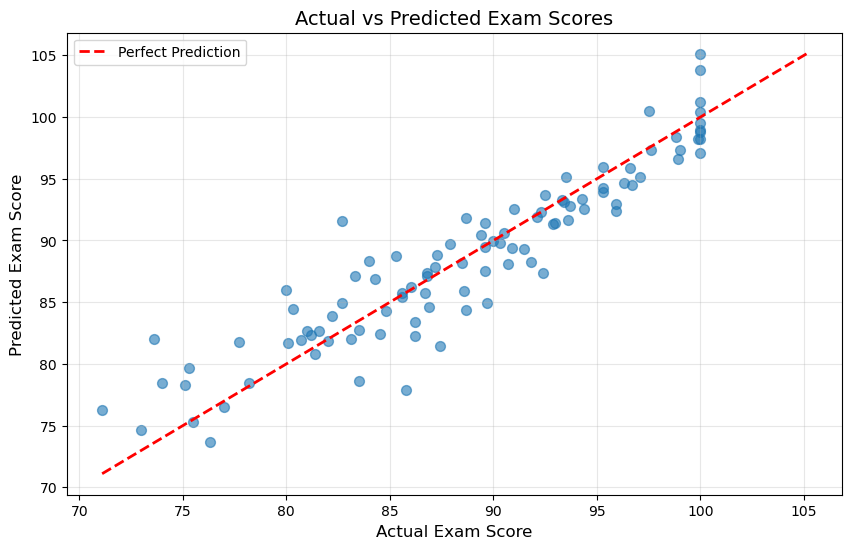

In [20]:
plt.figure(figsize=(10, 6))

# Plot actual vs predicted
plt.scatter(y_target, y_predicted, alpha=0.6, s=50)

# Plot the ideal line (where predicted = actual)
min_score = min(y_target.min(), y_predicted.min())
max_score = max(y_target.max(), y_predicted.max())
plt.plot([min_score, max_score], [min_score, max_score], 
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Exam Score', fontsize=12)
plt.ylabel('Predicted Exam Score', fontsize=12)
plt.title('Actual vs Predicted Exam Scores', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Question 2.4: Model Performance

1. Are the predictions close to the actual values?
2. Do you see any patterns in where the model makes larger errors?
3. Is a mean error of ~3-4 points considered good for this type of prediction?

**Answers:**
1. Yes, most predictions are quite close to the actual values - they cluster around the red diagonal line.
2. The errors appear relatively random, which is good - no systematic bias is visible.
3. Yes, a mean error of 3-4 points out of 100 is quite good, representing about 3-4% error.

## Step 7: Make Predictions for New Students

Now let's use our model to predict exam scores for new students!

In [21]:
# New students: [StudyHours, PreviousScore]
new_students = [
    [15, 70],   # Student A: Studies 15 hours, previous score 70
    [30, 85],   # Student B: Studies 30 hours, previous score 85
    [10, 90],   # Student C: Studies 10 hours, previous score 90
    [35, 65],   # Student D: Studies 35 hours, previous score 65
]

print("Predictions for new students:\n")
student_labels = ['A', 'B', 'C', 'D']
for i, student_data in enumerate(new_students):
    # Make prediction for this student
    pred_score = predict_score(np.array(student_data))
    print(f"Student {student_labels[i]}: "
          f"Studies {student_data[0]} hrs/week, Previous Score {student_data[1]} "
          f"-> Predicted Exam Score: {pred_score:.1f}")

Predictions for new students:

Student A: Studies 15 hrs/week, Previous Score 70 -> Predicted Exam Score: 80.4
Student B: Studies 30 hrs/week, Previous Score 85 -> Predicted Exam Score: 96.8
Student C: Studies 10 hrs/week, Previous Score 90 -> Predicted Exam Score: 84.4
Student D: Studies 35 hrs/week, Previous Score 65 -> Predicted Exam Score: 92.7


### Question 2.5: Analyze the Predictions

1. Which student is predicted to get the highest score? Does this make sense based on their features?
2. Compare Student A and Student C. Student C studies less but has a higher previous score. Who is predicted to do better? What does this tell you about the relative importance of the features?
3. If a student wants to improve their predicted score from 80 to 90, what could they do? (Consider the weights!)

**Answers:**
1. Student B (30 hours study, 85 previous score) is predicted to get the highest score, which makes sense as they have both high study hours and a good previous score.
2. Looking at the predictions, we can compare them. Since study hours has a higher weight (0.71 vs 0.38), increasing study time has a bigger impact.
3. To increase predicted score by 10 points, a student could: study ~14 more hours per week (10/0.71), or improve their baseline by ~26 points on a previous exam (10/0.38), or some combination.

### Create Your Own Prediction

Now it's your turn! Create a student profile and predict their exam score.

In [22]:
# Example: Create your own student
my_student = np.array([22, 78])  # Studies 22 hours, previous score 78

# Predict the exam score
my_prediction = predict_score(my_student)

print(f"My student: Studies {my_student[0]} hrs/week, Previous Score {my_student[1]}")
print(f"Predicted Exam Score: {my_prediction:.1f}")

My student: Studies 22 hrs/week, Previous Score 78
Predicted Exam Score: 88.4


---
# Reflection Questions

## Question 3.1: K-Means vs Linear Regression

Compare the two machine learning techniques you used:

1. What is the main difference between K-means clustering and linear regression?
2. K-means is **unsupervised learning** - what does this mean?
3. Linear regression is **supervised learning** - what does this mean?
4. Give an example of when you would use clustering vs. regression.

**Sample Answers:**
1. K-means groups similar data points together, while linear regression predicts a numerical value based on input features.
2. Unsupervised learning means we don't have labeled outcomes - we're just finding patterns in the data itself.
3. Supervised learning means we have labeled examples (input features and their corresponding outputs) that we learn from.
4. Use clustering when you want to discover natural groupings (e.g., customer segments). Use regression when you want to predict a specific value (e.g., house prices, test scores).

## Question 3.2: Real-World Applications

Think of a real-world problem you're interested in:

1. Describe a problem that could be solved with K-means clustering.
2. Describe a problem that could be solved with linear regression.
3. What data would you need to collect for each problem?

**Sample Answers:**
1. Clustering: Grouping songs by genre based on audio features like tempo, key, energy level.
2. Regression: Predicting apartment rent based on square footage, number of bedrooms, and distance from city center.
3. For clustering: Audio features for thousands of songs. For regression: Historical rental data with features and prices.

## Question 3.3: Model Limitations

Every model has limitations:

1. What are some limitations of K-means clustering? (Hint: think about choosing k, cluster shapes)
2. What are some limitations of linear regression? (Hint: think about the "linear" assumption)
3. For the student performance model, what important factors might be missing from our features?

**Sample Answers:**
1. K-means limitations: Must choose k in advance, assumes spherical clusters, sensitive to initialization, doesn't work well with clusters of very different sizes.
2. Linear regression limitations: Assumes linear relationships, sensitive to outliers, may not capture complex non-linear patterns.
3. Missing factors: Quality of study (not just hours), sleep quality, stress levels, course difficulty, teaching quality, natural aptitude for the subject, attendance.

---
# Congratulations!

You've successfully:
- ✅ Loaded and explored real-world datasets
- ✅ Applied K-means clustering to segment customers
- ✅ Predicted cluster membership for new data points
- ✅ Used a linear regression model to predict student performance
- ✅ Made predictions for new students
- ✅ Interpreted and evaluated your models

These are fundamental machine learning skills that you'll build upon in future courses!